# Βελτιστοποίηση Κατανομής Αποθήκευσης Μπαταρίας για Ενεργειακό Αρμπιτράζ και Εξομάλυνση Αιχμής

## Συνοπτική Παρουσίαση

Μια εμπορική εγκατάσταση συνδεδεμένη στο δίκτυο λειτουργεί μια μπαταρία ιόντων λιθίου 2 MW / 8 MWh παράλληλα με ένα μετρούμενο ηλεκτρικό φορτίο. Η εγκατάσταση χρεώνεται με δύο τρόπους: μια ωριαία τιμή ενέργειας **energy price** ($/MWh) της προηγούμενης ημέρας και μια μηνιαία **demand charge** στο μοναδικό υψηλότερο διάστημα εισαγωγής από το δίκτυο ($/MW). Ο διαχειριστής του περιουσιακού στοιχείου πρέπει να αποφασίζει, ώρα προς ώρα, πότε να φορτίζει τη μπαταρία (αγοράζοντας φθηνή ενέργεια και αυξάνοντας τη ζήτηση από το δίκτυο) και πότε να την εκφορτίζει (αντισταθμίζοντας ακριβή ενέργεια και μειώνοντας τη ζήτηση από το δίκτυο). Δύο ροές αξίας ανταγωνίζονται: **energy arbitrage** (αγορά χαμηλά τη νύχτα, εκφόρτιση στην απογευματινή αιχμή) και **peak shaving** (περιορισμός του χρεωμένου μεγίστου του δικτύου). Η φόρτιση δεν είναι δωρεάν — η απόδοση πλήρους κύκλου σημαίνει ότι περίπου το 10% της αποθηκευμένης ενέργειας χάνεται — έτσι το πρόγραμμα είναι μια γνήσια βελτιστοποίηση, όχι μια ευρετική μέθοδος.

Αυτό το notebook χτίζει την απόφαση από άκρη σε άκρη. Πρώτα συνθέτει μια ρεαλιστική καμπύλη τιμών 24 ωρών της προηγούμενης ημέρας (με πρωινές και απογευματινές αιχμές συν μια νυχτερινή κοιλάδα) και ένα συσχετισμένο προφίλ φορτίου της εγκατάστασης, στη συνέχεια τα προφιλάρει και τα δύο με το **PROC MEANS** και μια εύρωστη ζώνη τιμών εκατοστημορίων 2.5/97.5 του **PROC UNIVARIATE**. Ο πυρήνας είναι ένα γραμμικό πρόγραμμα στο **PROC OPTMODEL**: μεταβλητές απόφασης για ωριαία φόρτιση, εκφόρτιση και κατάσταση φόρτισης, συν μια μεταβλητή χρεωμένης αιχμής, υπό έναν αθροιστικό ισολογισμό κατάστασης φόρτισης (με ξεχωριστή απόδοση φόρτισης/εκφόρτισης), όρια ισχύος και χωρητικότητας, και έναν περιορισμό ορισμού αιχμής. Ο στόχος μεγιστοποιεί το περιθώριο αρμπιτράζ καθαρά από τη χρέωση ζήτησης. Το **PROC SQL** στη συνέχεια ποσοτικοποιεί το κόστος βασικής γραμμής έναντι βελτιστοποιημένου, και τρία πάνελ **PROC SGPLOT** οπτικοποιούν το πρόγραμμα φόρτισης/εκφόρτισης έναντι της τιμής, την τροχιά της κατάστασης φόρτισης, και το εξομαλυμένο προφίλ εισαγωγής από το δίκτυο.

**Αποτέλεσμα στη συνθετική ημέρα:** ο βελτιστοποιητής γεμίζει τη μπαταρία κατά τις φθηνότερες νυχτερινές ώρες, εκφορτίζει τόσο στην πρωινή όσο και στην απογευματινή αιχμή τιμών, επαναφορτίζει μέσω της μεσημβρινής κοιλάδας τιμών, και — κρίσιμα — συγκρατεί την ισχύ φόρτισής του ώστε να μη δημιουργεί ποτέ νέα αιχμή δικτύου. Το ημερήσιο κόστος ενέργειας πέφτει από **\$2,903.78 σε \$2,528.43** — **\$375.34 (12.9%) εξοικονόμηση από αρμπιτράζ** — ενώ το χρεωμένο μέγιστο του δικτύου πέφτει από **3.59 MW σε 3.43 MW** (περίπου **0.16 MW**), αξίας επιπλέον **\$18.98** στην υποτιθέμενη ημερήσια αναλογία χρέωσης ζήτησης. Το ίδιο μοντέλο κλιμακώνεται σε μεγαλύτερους ορίζοντες, πολλαπλά σενάρια τιμών, ή κυκλική λειτουργία με επίγνωση της υποβάθμισης απλώς επεκτείνοντας το σύνολο δεικτών και τους περιορισμούς.

## Πηγές Δεδομένων

Όλα τα δεδομένα είναι **συνθετικά**, δημιουργημένα ενσωματωμένα στο πρώτο κελί κώδικα με `CALL STREAMINIT(20260605)` για αναπαραγωγιμότητα. Χωρίς εξωτερικά αρχεία ή πρόσβαση δικτύου. Ένα σύνολο δεδομένων, `price_load`, με 24 ωριαίες γραμμές που αντιπροσωπεύουν μια μοναδική ημέρα λειτουργίας.

| Μεταβλητή | Τύπος | Μονάδες | Περιγραφή |
|----------|------|-------|-------------|
| `hour` | num | 0–23 | Ώρα της ημέρας λειτουργίας (δείκτης ορίζοντα) |
| `price` | num | $/MWh | Τιμή ενέργειας προηγούμενης ημέρας: νυχτερινή κοιλάδα, πρωινές + απογευματινές αιχμές, με γκαουσιανό θόρυβο (κατώφλι στα $5) |
| `load` | num | MW | Ηλεκτρική ζήτηση εγκατάστασης, συσχετισμένη με την ημερήσια δραστηριότητα (κατώφλι στα 0.3 MW) |
| `day_type` | char | — | Σημαία παραθύρου τιμολόγησης: `PeakTOU` (ώρες 17–21) έναντι `OffPeak`, χρησιμοποιείται για τη σύνοψη διαφοράς τιμών αιχμής/εκτός αιχμής |

Οι παράμετροι της μπαταρίας είναι σταθερές του μοντέλου εντός του PROC OPTMODEL: 8 MWh χρησιμοποιήσιμη χωρητικότητα, 2 MW μέγιστη ισχύς φόρτισης/εκφόρτισης, 0.95 απόδοση φόρτισης και 0.95 απόδοση εκφόρτισης (~90% πλήρης κύκλος), αρχική κατάσταση φόρτισης 0 MWh, και χρέωση ζήτησης \$120/MW που εφαρμόζεται στη χρεωμένη αιχμή δικτύου της ημέρας (το ημερησίως αποσβεσμένο μερίδιο μιας μηνιαίας χρέωσης ζήτησης).

# Βελτιστοποίηση Κατανομής Αποθήκευσης Μπαταρίας
## Ενεργειακό αρμπιτράζ και εξομάλυνση αιχμής για μια εγκατάσταση συνδεδεμένη στο δίκτυο

Μια εμπορική εγκατάσταση λειτουργεί μια **μπαταρία 2 MW / 8 MWh** πίσω από τον μετρητή της. Ο λογαριασμός ηλεκτρικού της έχει δύο μέρη: μια ωριαία **energy price** ($/MWh) και μια μηνιαία **demand charge** στο μοναδικό υψηλότερο διάστημα εισαγωγής από το δίκτυο ($/MW). Ο διαχειριστής θέλει ένα ωριαίο πρόγραμμα φόρτισης/εκφόρτισης που να αποτυπώνει δύο ροές αξίας ταυτόχρονα:

- **Αρμπιτράζ** — αποθήκευση φθηνής νυχτερινής ενέργειας, απελευθέρωσή της κατά τις ακριβές ώρες αιχμής.
- **Εξομάλυνση αιχμής** — εκφόρτιση κατά την ακίδα ζήτησης για μείωση του χρεωμένου μεγίστου του δικτύου.

Επειδή η απόδοση πλήρους κύκλου χάνει ~10% της αποθηκευμένης ενέργειας, ο συμβιβασμός δεν είναι τετριμμένος και δικαιολογεί μια πραγματική βελτιστοποίηση. Τον διατυπώνουμε ως γραμμικό πρόγραμμα στο **PROC OPTMODEL**, στη συνέχεια ποσοτικοποιούμε και οπτικοποιούμε το αποτέλεσμα.

> Όλα τα παρακάτω δεδομένα είναι συνθετικά και δημιουργούνται ενσωματωμένα — το notebook είναι πλήρως αυτοτελές και εκτελείται σε λίγα δευτερόλεπτα.

## 1. Δημιουργία συνθετικού προφίλ τιμών και φορτίου προηγούμενης ημέρας

Χτίζουμε μία ημέρα λειτουργίας (24 ωριαίες γραμμές). Η καμπύλη τιμών έχει μια νυχτερινή κοιλάδα και πρωινές + απογευματινές αιχμές· το φορτίο της εγκατάστασης συσχετίζεται με την ημερήσια δραστηριότητα. Ένας σταθερός σπόρος διατηρεί την εκτέλεση αναπαραγώγιμη. Επίσης σημειώνουμε το θεσμοθετημένο παράθυρο αιχμής χρόνου χρήσης ώστε να μπορούμε να συνοψίσουμε αργότερα τη διαφορά αιχμής/εκτός αιχμής.

In [1]:
ΔΕΔΟΜΕΝΑ price_load;
    CALL streaminit(20260605);
    LENGTH day_type $20;
    ΕΠΑΝΑΛΗΨΗ hour = 0 ΕΩΣ 23;
        /* Ημερήσια τιμή ενέργειας ($/MWh): πρωινή + βραδινή αιχμή */
        BASE = 38
             + 26 * EXP(-((hour - 8)**2) / 6)
             + 40 * EXP(-((hour - 19)**2) / 5)
             - 14 * EXP(-((hour - 3)**2) / 8);
        price = round(BASE + rand('normal', 0, 4), 0.01);
        ΕΑΝ price < 5 ΤΟΤΕ price = 5;

        /* Φορτίο εγκατάστασης (MW): νυχτερινή ύφεση, βραδινή άνοδος */
        LOAD = round(2.0
             + 1.6 * EXP(-((hour - 19)**2) / 7)
             + 0.7 * EXP(-((hour - 9)**2) / 10)
             + rand('normal', 0, 0.10), 0.01);
        ΕΑΝ LOAD < 0.3 ΤΟΤΕ LOAD = 0.3;

        ΕΑΝ hour >= 17 AND hour <= 21 ΤΟΤΕ day_type = 'Αιχμή';
        ΑΛΛΙΩΣ day_type = 'Εκτός αιχμής';
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΕΤΙΚΕΤΑ hour='Ώρα ημέρας' price='Τιμή ($/MWh)' LOAD='Φορτίο (MW)' day_type='Τύπος ημέρας';
    ΑΦΑΙΡΕΣΗ BASE;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA price_load


NOTE: Wrote price_load (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Προφιλάρισμα των κατανομών τιμών και φορτίου

Πριν από τη βελτιστοποίηση, ελέγχουμε τη λογική των εισόδων. Η διαφορά μεταξύ των φθηνότερων και των ακριβότερων ωρών είναι αυτό που το αρμπιτράζ αξιοποιεί, και το μέγιστο φορτίο αγκυρώνει την ευκαιρία εξομάλυνσης αιχμής.

In [2]:
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=price_load n mean std MIN MAX maxdec=2;
    ΜΕΤΑΒΛΗΤΗ price LOAD;
    TITLE 'Περιγραφικά στατιστικά τιμής και φορτίου';
ΕΚΤΕΛΕΣΗ;

                                        Περιγραφικά στατιστικά τιμής και φορτίου                                        

                                                  The MEANS Procedure

 Variable  Label                    N        Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------------------------
 price     Τιμή ($/MWh)            24       46.29       15.81       18.57       79.27
 LOAD      Φορτίο (MW)             24        2.47        0.48        1.71        3.59
 ------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Διαφορά τιμών αιχμής έναντι εκτός αιχμής

Η ομαδοποίηση κατά τη σημαία χρόνου χρήσης δείχνει πόσο πλουσιότερες είναι οι ώρες αιχμής σε σχέση με τη βασική γραμμή εκτός αιχμής — το δομικό σήμα που εκμεταλλεύεται η μπαταρία.

In [3]:
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=price_load mean MIN MAX maxdec=2;
    ΚΛΑΣΗ day_type;
    ΜΕΤΑΒΛΗΤΗ price;
    TITLE 'Τιμή ανά τύπο ημέρας (αιχμή έναντι εκτός αιχμής)';
ΕΚΤΕΛΕΣΗ;

                                    Τιμή ανά τύπο ημέρας (αιχμή έναντι εκτός αιχμής)                                    

                                                  The MEANS Procedure

                                      Analysis Variable : price Τιμή ($/MWh)

                                                       N
                          Τύπος ημέρας               Obs       Mean      Minimum      Maximum
                          -------------------------------------------------------------------
                          Αιχμή                        5      68.45        54.88        79.27
                          Εκτός αιχμ                  19      40.46        18.57        54.89
                          -------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Εύρωστη ζώνη τιμών (εκατοστημόρια 2.5 / 97.5)

Χαρακτηρίζουμε τις ουρές των τιμών με μια ζώνη εκατοστημορίων 2.5 / 97.5. Το **PROC UNIVARIATE** με `PCTLPTS=` υπολογίζει αυθαίρετα εκατοστημόρια καθαρά, που είναι το σωστό εργαλείο για κλασματικά εκατοστημόρια.

In [4]:
ΔΙΑΔΙΚΑΣΙΑ UNIVARIATE ΔΕΔΟΜΕΝΑ=price_load NOPRINT;
    ΜΕΤΑΒΛΗΤΗ price;
    ΕΞΟΔΟΣ out=price_band pctlpts=2.5 97.5 pctlpre=p_;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=price_band noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ p_2_5='2,5ό εκατοστημόριο τιμής' p_97_5='97,5ό εκατοστημόριο τιμής';
    TITLE 'Ζώνη τιμής: κεντρικό 95% της ημερήσιας κατανομής';
ΕΚΤΕΛΕΣΗ;

                                    Ζώνη τιμής: κεντρικό 95% της ημερήσιας κατανομής                                    

                   2,5ό εκατοστημόριο τιμής                     97,5ό εκατοστημόριο τιμής
                                      18.57                                         79.27




NOTE: PROC UNIVARIATE
NOTE: Output dataset price_band has 1 observations and 2 variables.
NOTE: PROC PRINT data=price_band

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 5. Η βελτιστοποίηση κατανομής (γραμμικό πρόγραμμα)

Διαβάζουμε την ωριαία τιμή και το φορτίο στο PROC OPTMODEL και δηλώνουμε:

- `chg[h]`, `dis[h]` — ωριαία ισχύς φόρτισης / εκφόρτισης (MW), οριοθετημένη από τη διαβάθμιση αντιστροφέα 2 MW.
- `soc[h]` — κατάσταση φόρτισης (MWh), οριοθετημένη από τη χρησιμοποιήσιμη χωρητικότητα 8 MWh.
- `peak` — το χρεωμένο μέγιστο του δικτύου (MW).

**Περιορισμοί.** Το `soc_balance` συσσωρεύει την καθαρή ενέργεια σε κάθε ώρα με ξεχωριστή απόδοση φόρτισης/εκφόρτισης (μια μορφή τρέχοντος αθροίσματος της ωριαίας αναδρομής). Το `peak_def` αναγκάζει το `peak` να κυριαρχεί σε κάθε ωριαία καθαρή εισαγωγή από το δίκτυο, ώστε η ελαχιστοποίησή του να εξομαλύνει τη χρέωση ζήτησης.

**Στόχος.** Μεγιστοποίηση του περιθωρίου αρμπιτράζ — `price × (discharge − charge)` αθροισμένο σε όλη την ημέρα — μείον τη χρέωση ζήτησης στη χρεωμένη αιχμή. Επιλύουμε ως συνεχές LP.

In [5]:
ΔΙΑΔΙΚΑΣΙΑ optmodel;
    ΟΡΙΣΜΟΣ HOURS;
    num price{HOURS};
    num LOAD{HOURS};

    READ ΔΕΔΟΜΕΝΑ price_load INTO HOURS=[hour]
        price=price col=price
        LOAD=LOAD col=LOAD;

    /* Μπαταρία: 8 MWh ωφέλιμα, 2 MW ισχύς, ~90% απόδοση κύκλου */
    num capacity   = 8.0;
    num p_max      = 2.0;
    num eta_chg    = 0.95;
    num eta_dis    = 0.95;
    num soc0       = 0.0;
    num dt         = 1.0;
    /* Demand charge applied to this day's billed grid peak ($/MW).
       Commercial demand charges are monthly; 120 is the marginal value of
       shaving today's grid maximum once the monthly charge is amortized to
       the day. It is large enough that the optimizer will hold charging
       power back rather than create a new, higher peak. */
    num demand_chg = 120;

    /* Μεταβλητές απόφασης (MW φόρτιση/εκφόρτιση, MWh κατάσταση φόρτισης) */
    ΜΕΤΑΒΛΗΤΗ chg{HOURS}  >= 0 <= p_max;
    ΜΕΤΑΒΛΗΤΗ dis{HOURS}  >= 0 <= p_max;
    ΜΕΤΑΒΛΗΤΗ soc{HOURS}  >= 0 <= capacity;
    ΜΕΤΑΒΛΗΤΗ peak        >= 0;   /* billed grid peak (MW) for demand charge */

    /* Καθαρή εισαγωγή δικτύου μετά τη δράση της μπαταρίας (MW) */
    impvar grid_mw{h IN HOURS} = LOAD[h] + chg[h] - dis[h];

    /* Cumulative state of charge: energy in less energy out through hour h,
       with charge/discharge efficiency applied. Equivalent to an hourly
       recurrence but stated as a running sum over prior hours. */
    con soc_balance{h IN HOURS}:
        soc[h] = soc0
                 + sum{k IN HOURS: k <= h}
                     (eta_chg * chg[k] - dis[k] / eta_dis) * dt;

    /* Εξομάλυνση αιχμής: η χρεούμενη αιχμή είναι η μέγιστη ημερήσια εισαγωγή */
    con peak_def{h IN HOURS}: peak >= grid_mw[h];

    /* Μεγιστοποίηση περιθωρίου αρμπιτράζ ενέργειας μείον τη χρέωση ζήτησης αιχμής */
    MAX net_value =
        sum{h IN HOURS} price[h] * (dis[h] - chg[h]) * dt
        - demand_chg * peak;

    solve WITH lp;

    CREATE ΔΕΔΟΜΕΝΑ dispatch FROM [hour=HOURS]
        price=price[hour]
        LOAD=LOAD[hour]
        charge_mw=chg[hour]
        discharge_mw=dis[hour]
        soc_mwh=soc[hour]
        grid_mw=grid_mw[hour];
QUIT;

                                    Ζώνη τιμής: κεντρικό 95% της ημερήσιας κατανομής                                    


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Maximization
  Objective Function            NET_VALUE
  Objective Type                Linear

  Number of Variables           73
  Bounded Above                 0
  Bounded Below                 1
  Bounded Below and Above       72
  Free                          0
  Fixed                         0

  Number of Constraints         48

                          Solution Summary
  Solver                        LP
  Objective Function            NET_VALUE
  Solution Status               Optimal
  Objective Value               -36.4771665526




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 6. Το βέλτιστο ωριαίο πρόγραμμα

Ο επιλυμένος πίνακας δείχνει τη φόρτιση κατανεμημένη στις φθηνές νυχτερινές και μεσημβρινές ώρες — μετριασμένη σε περίπου 1.0–1.7 MW ώστε να μη θέτει ποτέ νέα αιχμή δικτύου — την εκφόρτιση συγκεντρωμένη στις πρωινές και απογευματινές αιχμές τιμών, και την κατάσταση φόρτισης να ιχνηλατεί έναν λογικό κύκλο γεμίσματος-και-απελευθέρωσης εντός του ορίου των 8 MWh. Η στήλη `grid_mw` κρατά μια επίπεδη οροφή ~3.43 MW σε κάθε ώρα φόρτισης, την υπογραφή του δεσμευτικού περιορισμού αιχμής.

In [6]:
ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=dispatch noobs ΕΤΙΚΕΤΑ;
    ΜΕΤΑΒΛΗΤΗ hour price LOAD charge_mw discharge_mw soc_mwh grid_mw;
    ΕΤΙΚΕΤΑ hour='Ώρα ημέρας' price='Τιμή ($/MWh)' LOAD='Φορτίο (MW)'
          charge_mw='Φόρτιση (MW)' discharge_mw='Εκφόρτιση (MW)'
          soc_mwh='Κατάσταση φόρτισης (MWh)' grid_mw='Εισαγωγή δικτύου (MW)';
    TITLE 'Βέλτιστο ωριαίο πρόγραμμα λειτουργίας μπαταρίας';
ΕΚΤΕΛΕΣΗ;

                                    Βέλτιστο ωριαίο πρόγραμμα λειτουργίας μπαταρίας                                     

         Ώρα ημέρας      Τιμή ($/MWh)        Φορτίο (MW)         Φόρτιση (MW)           Εκφόρτιση (MW)                   Κατάσταση φόρτισης (MWh)                 Εισαγωγή δικτύου (MW)
                  0             29.73               1.99            1.4418421                        0                                    1.36975                             3.4318421
                  1             28.03               2.16            1.2718421                        0                                      2.578                             3.4318421
                  2             21.87                  2            1.4318421                        0                                    3.93825                             3.4318421
                  3             18.57               1.71            1.7218421                        0                                      5.


NOTE: PROC PRINT data=dispatch

NOTE: PROC PRINT completed: 24 observations printed, 7 variables


## 7. Κύριοι δείκτες KPI: βασική γραμμή έναντι βελτιστοποιημένου

Συγκρίνουμε τη βασική γραμμή αδράνειας (πληρωμή της τιμής για το ακατέργαστο φορτίο κάθε ώρα) έναντι της βελτιστοποιημένης θέσης δικτύου, και αναφέρουμε την εξοικονόμηση από αρμπιτράζ, τη μείωση της χρεωμένης αιχμής, και τη δολαριακή αξία αυτής της μείωσης στη χρέωση ζήτησης — τους δύο μοχλούς που καθορίζουν την επιχειρηματική περίπτωση.

In [7]:
ΔΙΑΔΙΚΑΣΙΑ SQL;
    CREATE TABLE kpi AS
    ΕΠΙΛΟΓΗ
        sum(price * LOAD)                        AS base_energy_cost,
        sum(price * grid_mw)                     AS opt_energy_cost,
        sum(price * LOAD) - sum(price * grid_mw) AS arbitrage_savings,
        MAX(LOAD)                                AS base_peak_mw,
        MAX(grid_mw)                             AS opt_peak_mw,
        MAX(LOAD) - MAX(grid_mw)                 AS peak_reduction_mw,
        120 * (MAX(LOAD) - MAX(grid_mw))         AS demand_charge_savings
    FROM dispatch;
QUIT;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=kpi noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ base_energy_cost='Κόστος ενέργειας βάσης'
          opt_energy_cost='Βελτιστοποιημένο κόστος ενέργειας'
          arbitrage_savings='Εξοικονόμηση από αρμπιτράζ'
          base_peak_mw='Αιχμή βάσης (MW)'
          opt_peak_mw='Βελτιστοποιημένη αιχμή (MW)'
          peak_reduction_mw='Μείωση αιχμής (MW)'
          demand_charge_savings='Εξοικονόμηση χρέωσης ζήτησης';
    TITLE 'Δείκτες απόδοσης: εξοικονόμηση κόστους και μείωση αιχμής';
ΕΚΤΕΛΕΣΗ;

                                    Βέλτιστο ωριαίο πρόγραμμα λειτουργίας μπαταρίας                                     

                                Δείκτες απόδοσης: εξοικονόμηση κόστους και μείωση αιχμής                                

                    Κόστος ενέργειας βάσης                                 Βελτιστοποιημένο κόστος ενέργειας                          Εξοικονόμηση από αρμπιτράζ            Αιχμή βάσης (MW)                       Βελτιστοποιημένη αιχμή (MW)              Μείωση αιχμής (MW)                            Εξοικονόμηση χρέωσης ζήτησης
                                 2903.7774                                                   2528.4335145526                                      375.3438854474                        3.59                                         3.4318421                       0.1581579                                               18.978948




NOTE: PROC SQL 

NOTE: Table kpi created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=kpi

NOTE: PROC PRINT completed: 1 observations printed, 7 variables


## 8. Πρόγραμμα φόρτισης / εκφόρτισης έναντι τιμής

Η φόρτιση (μπλε βελόνες) και η εκφόρτιση (κόκκινη γραμμή με δείκτες) μοιράζονται τον αριστερό άξονα μεγαβάτ· η τιμή προηγούμενης ημέρας (πράσινη διακεκομμένη) διαβάζεται στα δεξιά. Η φόρτιση συγκεντρώνεται στις φθηνές νυχτερινές και μεσημβρινές ώρες, ενώ η εκφόρτιση πυροδοτείται στις πρωινές και απογευματινές αιχμές τιμών — η οπτική επιβεβαιώνει ότι ο βελτιστοποιητής αγοράζει χαμηλά και πουλά υψηλά.

                                Δείκτες απόδοσης: εξοικονόμηση κόστους και μείωση αιχμής                                




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


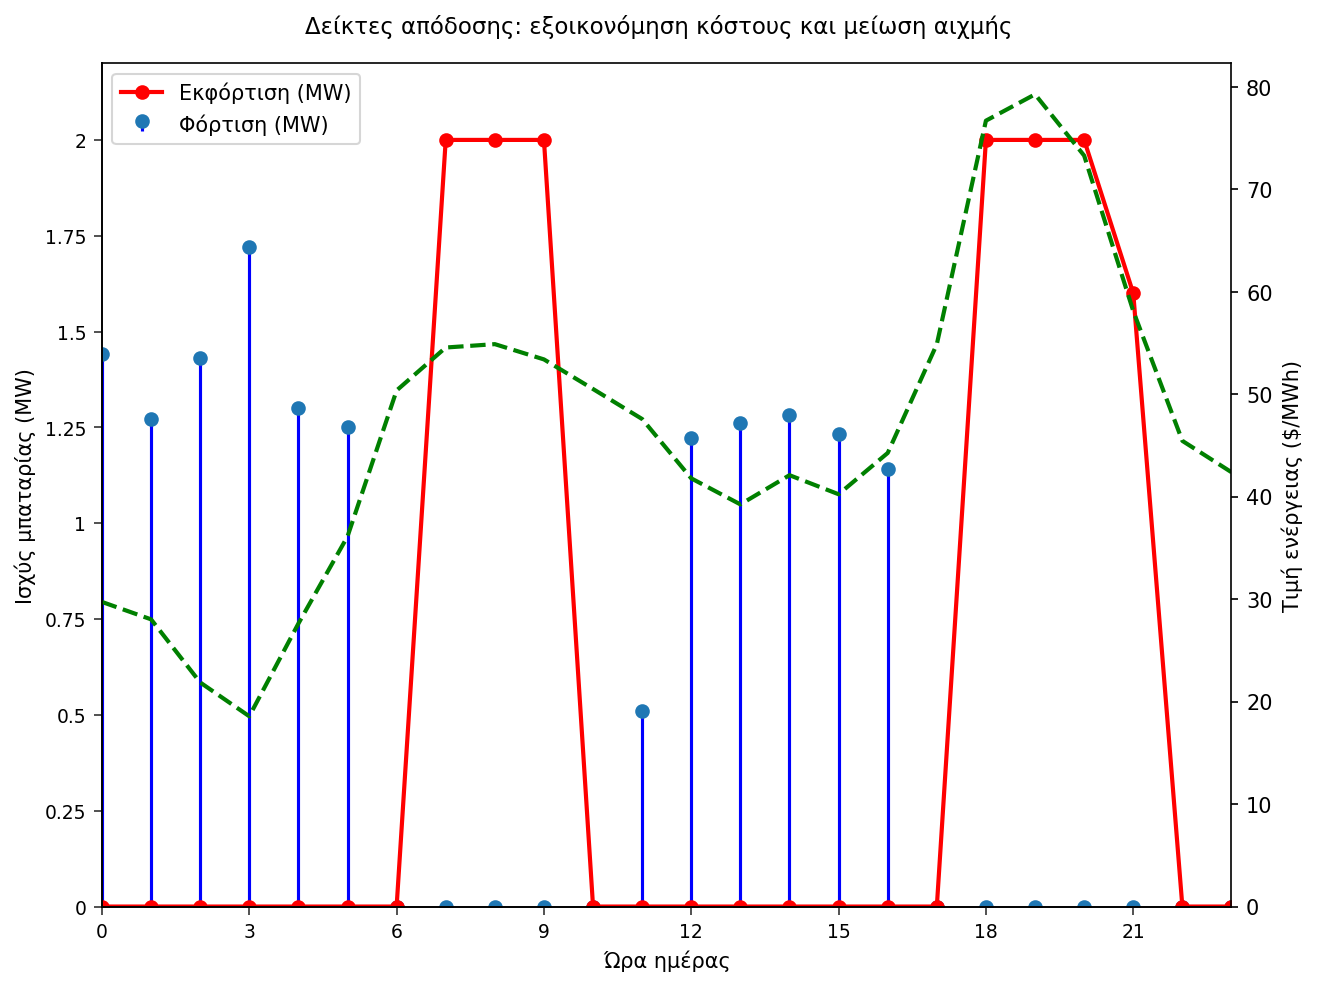

In [8]:
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=dispatch;
    needle x=hour y=charge_mw / LINEATTRS=(color=blue thickness=3)
        legendlabel="Φόρτιση (MW)";
    SERIES x=hour y=discharge_mw / LINEATTRS=(color=red thickness=2)
        MARKERS legendlabel="Εκφόρτιση (MW)";
    SERIES x=hour y=price / y2axis LINEATTRS=(color=green pattern=dash thickness=2)
        legendlabel="Τιμή ($/MWh)";
    XAXIS ΕΤΙΚΕΤΑ="Ώρα ημέρας" VALUES=(0 ΕΩΣ 23 ΚΑΤΑ 3);
    YAXIS ΕΤΙΚΕΤΑ="Ισχύς μπαταρίας (MW)" MIN=0 MAX=2.2;
    y2axis ΕΤΙΚΕΤΑ="Τιμή ενέργειας ($/MWh)" MIN=0;
ΕΚΤΕΛΕΣΗ;

## 9. Τροχιά κατάστασης φόρτισης

Η αποθηκευμένη ενέργεια ανεβαίνει καθώς η μπαταρία γεμίζει τη νύχτα, αντλείται σε κάθε παράθυρο εκφόρτισης, και δεν παραβιάζει ποτέ την οροφή χρησιμοποιήσιμης χωρητικότητας των 8 MWh (διακεκομμένη αναφορά).

                                Δείκτες απόδοσης: εξοικονόμηση κόστους και μείωση αιχμής                                




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


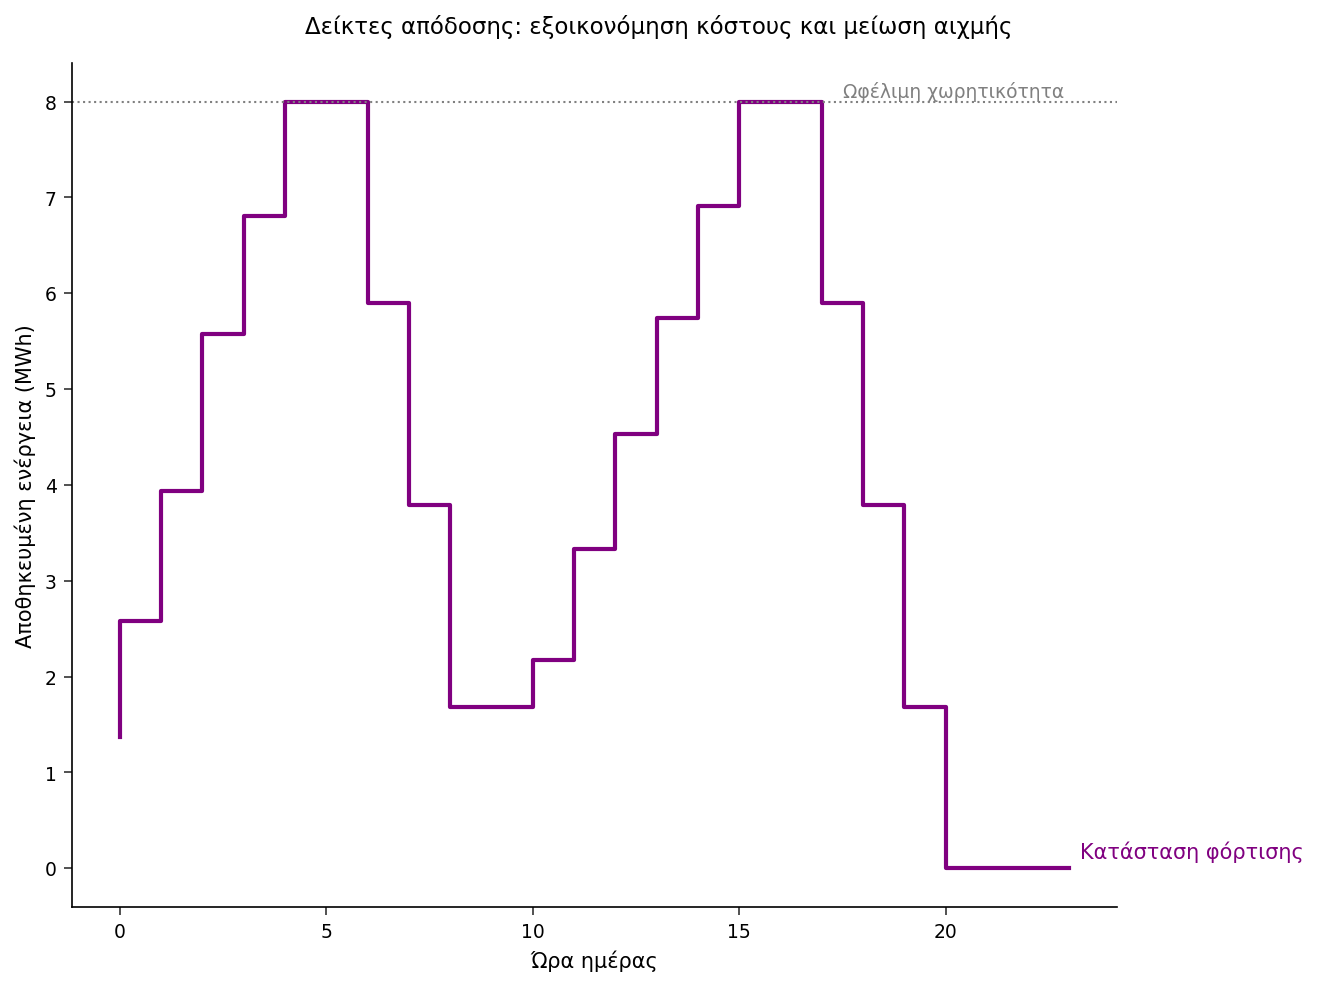

In [9]:
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=dispatch;
    STEP x=hour y=soc_mwh / LINEATTRS=(color=purple thickness=2)
        curvelabel="Κατάσταση φόρτισης";
    REFLINE 8 / AXIS=y LINEATTRS=(color=grey pattern=dot)
        ΕΤΙΚΕΤΑ="Ωφέλιμη χωρητικότητα";
    XAXIS ΕΤΙΚΕΤΑ="Ώρα ημέρας";
    YAXIS ΕΤΙΚΕΤΑ="Αποθηκευμένη ενέργεια (MWh)";
ΕΚΤΕΛΕΣΗ;

## 10. Εισαγωγή από το δίκτυο: πριν και μετά την κατανομή

Η πορτοκαλί γραμμή (εισαγωγή από το δίκτυο με τη μπαταρία) πέφτει αρκετά κάτω από το διακεκομμένο βασικό φορτίο κατά την απογευματινή άνοδο (ώρες 18–21) — το φαινόμενο εξομάλυνσης αιχμής που μειώνει τη χρέωση ζήτησης. Κατά τα νυχτερινά και μεσημβρινά παράθυρα φόρτισης ανεβαίνει, αλλά ο βελτιστοποιητής την περιορίζει σε μια επίπεδη οροφή ~3.43 MW που παραμένει *κάτω* από την αρχική αιχμή φορτίου 3.59 MW, ώστε η φόρτιση να αγοράζει φθηνή ενέργεια χωρίς να θέτει νέο χρεωμένο μέγιστο.

                                Δείκτες απόδοσης: εξοικονόμηση κόστους και μείωση αιχμής                                




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


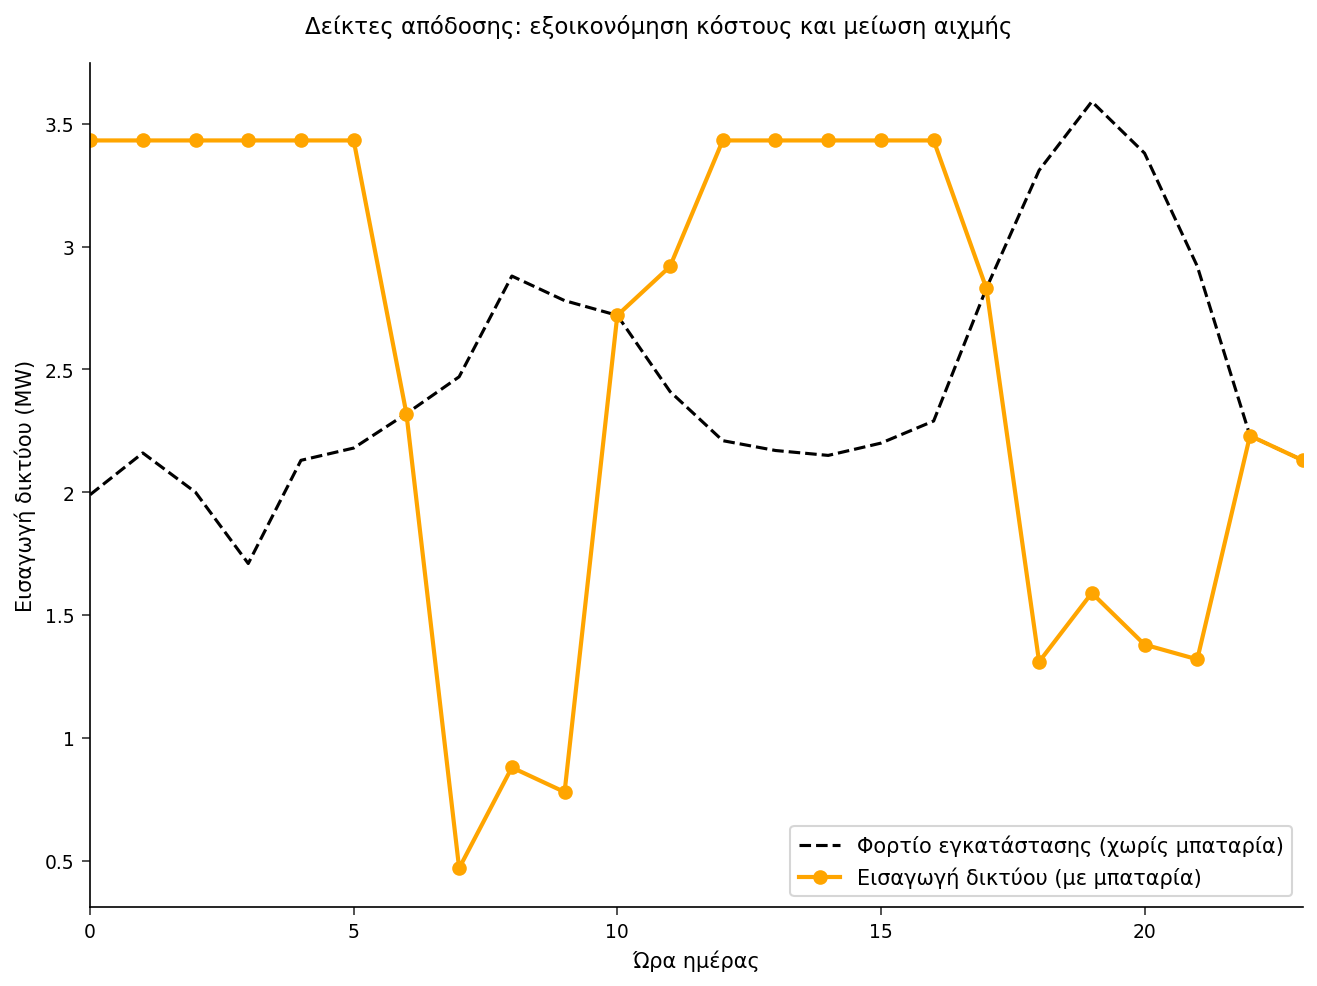

In [10]:
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=dispatch;
    SERIES x=hour y=LOAD / LINEATTRS=(color=black pattern=dash)
        legendlabel="Φορτίο εγκατάστασης (χωρίς μπαταρία)";
    SERIES x=hour y=grid_mw / LINEATTRS=(color=orange thickness=2)
        MARKERS legendlabel="Εισαγωγή δικτύου (με μπαταρία)";
    XAXIS ΕΤΙΚΕΤΑ="Ώρα ημέρας";
    YAXIS ΕΤΙΚΕΤΑ="Εισαγωγή δικτύου (MW)";
ΕΚΤΕΛΕΣΗ;

## Ερμηνεία και επόμενα βήματα

**Τι αποφάσισε το μοντέλο.** Με την απόδοση πλήρους κύκλου να επιβαρύνει κάθε κύκλο, ο βελτιστοποιητής βρήκε παρ' όλα αυτά σαφή αξία: γέμισε τη μπαταρία κατά τις φθηνότερες νυχτερινές ώρες, εκφόρτισε στην πρωινή αιχμή τιμών (ώρες 7–9), επαναφόρτισε μέσω της μεσημβρινής κοιλάδας τιμών (ώρες 11–16), και εκφόρτισε ξανά στην πλουσιότερη απογευματινή αιχμή (ώρες 18–21). Χαρακτηριστικά, φόρτισε σε μόλις 1.0–1.7 MW αντί για την πλήρη διαβάθμιση των 2 MW κατά το νυχτερινό γέμισμα — συγκρατώντας την ισχύ ώστε η πρόσθετη ζήτηση από το δίκτυο να μην ωθήσει ποτέ την εισαγωγή πάνω από την αιχμή φορτίου της ημέρας. Η κατάσταση φόρτισης σεβάστηκε τόσο τη χωρητικότητα των 8 MWh όσο και το όριο ισχύος των 2 MW ανά πάσα στιγμή.

**Η επιχειρηματική περίπτωση.** Το ημερήσιο κόστος ενέργειας έπεσε από **\$2,903.78 σε \$2,528.43** — **\$375.34 (12.9%)** εξοικονόμηση από αρμπιτράζ — και το χρεωμένο μέγιστο του δικτύου έπεσε από **3.59 MW σε 3.43 MW** (περίπου **0.16 MW**), κόβοντας επιπλέον **\$18.98** από τη γραμμή χρέωσης ζήτησης. Ετησιοποιημένη σε όλες τις ημέρες λειτουργίας συν την επαναλαμβανόμενη μείωση χρέωσης ζήτησης, αυτό είναι το είδος του περιθωρίου που στηρίζει μια επένδυση αποθήκευσης.

**Γιατί ένα LP είναι το σωστό εργαλείο.** Οι ευρετικές μέθοδοι ("φόρτιση κάτω από τη διάμεση τιμή, εκφόρτιση πάνω από αυτήν") αγνοούν τις απώλειες απόδοσης, τη σύζευξη χωρητικότητας μεταξύ ωρών, και το γεγονός ότι η χρέωση ζήτησης εξαρτάται από ένα μοναδικό διάστημα — θα φόρτιζαν σε πλήρη ισχύ τη νύχτα και θα *αύξαναν* τη χρεωμένη αιχμή, καταστρέφοντας την αξία εξομάλυνσης αιχμής. Το PROC OPTMODEL αποτυπώνει όλα αυτά σε ένα δηλωτικό μοντέλο και επιστρέφει το αποδεδειγμένα βέλτιστο πρόγραμμα, το οποίο εδώ μετριάζει σκόπιμα τον ρυθμό φόρτισης για να προστατεύσει την αιχμή.

**Επέκταση του μοντέλου.**

- **Μεγαλύτεροι ορίζοντες / πολυήμεροι** — διεύρυνση του συνόλου δεικτών `HOURS`· προσθήκη ορίων κυκλικής λειτουργίας μεταξύ ημερών.
- **Αβεβαιότητα τιμών** — επίλυση του LP σε πολλαπλά σενάρια τιμών και υπολογισμός του μέσου όρου της απόφασης της πρώτης ώρας (μια κυλιόμενη στοχαστική πολιτική).
- **Υποβάθμιση μπαταρίας** — προσθήκη ενός όρου ποινής διαμεταγωγής ή ενός περιορισμού στους αθροιστικούς κύκλους για να σταθμιστεί το αρμπιτράζ έναντι της διάρκειας ζωής του περιουσιακού στοιχείου.
- **Απόκριση συχνότητας / αγορές χωρητικότητας** — εισαγωγή περιορισμών δεσμευμένου περιθωρίου ώστε η μπαταρία να μπορεί να σωρεύει έσοδα βοηθητικών υπηρεσιών πάνω από το αρμπιτράζ.

Όλα αυτά είναι σταδιακές επεξεργασίες του ίδιου μπλοκ OPTMODEL — η δομή που καθιερώθηκε εδώ μεταφέρεται αναλλοίωτη.